<a href="https://colab.research.google.com/github/KomalSinghMarkam/codec-technologies-projects/blob/main/HandwrittenDigitRecognizer_(MNIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Step 3: Preprocess data
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [4]:
# Step 4: Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Step 5: Compile & Train
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9428 - loss: 0.2011 - val_accuracy: 0.9783 - val_loss: 0.0673
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.9834 - loss: 0.0545 - val_accuracy: 0.9859 - val_loss: 0.0466
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.9886 - loss: 0.0386 - val_accuracy: 0.9914 - val_loss: 0.0292
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.9905 - loss: 0.0295 - val_accuracy: 0.9885 - val_loss: 0.0341
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9906 - val_loss: 0.0298


In [6]:
# Step 6: Evaluate
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9906 - loss: 0.0298
Test Accuracy: 99.06%


In [7]:
# Step 7: Test Prediction on Random Image
import matplotlib.pyplot as plt
import numpy as np

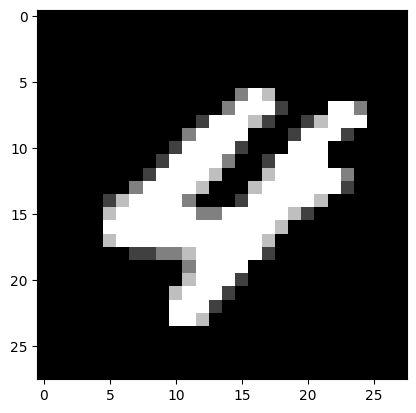

In [8]:
# Pick a random test image
index = np.random.randint(0, len(x_test))
plt.imshow(x_test[index].reshape(28,28), cmap="gray")
plt.show()

In [9]:
# Predict
prediction = model.predict(x_test[index].reshape(1,28,28,1))
print("Predicted Digit:", prediction.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Digit: 4
